# Задача 2. Моделирование динамики популяций видов

### Прогнозировать изменения численности видов в пищевой цепочке на основе временных рядов.

В работе используется датасет Figshare predator-prey cycles, содержащий экспериментальные временные ряды динамики популяций в системе “жертва-хищник”. Основными анализируемыми переменными являются algae, то есть водоросли как ресурс, и rotifers, то есть коловратки как потребитель.

## Загрузка датасета


In [ ]:
import zipfile
from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ZIP_PATH = Path("/content/10045976.zip")
EXTRACT_DIR = Path("/content/figshare_predator_prey")

EXTRACT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

csv_files = sorted(EXTRACT_DIR.glob("*.csv"))

Каждая таблица датасета является отдельным экспериментальным временным рядом. Их нельзя склеивать как один непрерывный ряд, потому что конец одного эксперимента не является началом следующего. Поэтому ниже каждому ряду добавляется отдельный `cycle_id`.


In [ ]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    rename = {}
    for c in df.columns:
        low = c.lower().strip()

        if "time" in low:
            rename[c] = "time"
        elif "algae" in low:
            rename[c] = "algae"
        elif "rotifer" in low:
            rename[c] = "rotifers"
        elif "egg-ratio" in low or "egg ratio" in low:
            rename[c] = "egg_ratio"
        elif "eggs" in low:
            rename[c] = "eggs"
        elif "dead" in low:
            rename[c] = "dead_animals"
        elif "external" in low or "medium" in low:
            rename[c] = "external_medium"

    df = df.rename(columns=rename)

    for col in df.columns:
        if col != "cycle_id":
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


raw_frames = []

for file_path in csv_files:
    df = pd.read_csv(file_path)
    df = standardize_columns(df)
    df["cycle_id"] = Path(file_path).stem
    raw_frames.append(df)

raw_data = pd.concat(raw_frames, ignore_index=True)

print("Размер объединенной таблицы:", raw_data.shape)
display(raw_data.head())
display(raw_data.groupby("cycle_id").agg(
    observations=("time", "count"),
    start_day=("time", "min"),
    end_day=("time", "max"),
    missing_algae=("algae", lambda s: s.isna().sum()),
    missing_rotifers=("rotifers", lambda s: s.isna().sum())
))


Размер объединенной таблицы: (1953, 8)


,time,algae,rotifers,egg_ratio,eggs,dead_animals,external_medium,cycle_id
0,0.00,1.50,NaN,NaN,NaN,NaN,80.0,C1
1,0.95,0.83,5.42,0.00,0.00,0.4,80.0,C1
2,2.26,0.70,18.26,0.38,7.02,0.0,80.0,C1
3,2.91,0.38,17.86,0.19,3.41,0.4,80.0,C1
4,3.95,0.41,21.07,0.32,6.82,0.4,80.0,C1


,observations,start_day,end_day,missing_algae,missing_rotifers
cycle_id,,,,,
C1,366,0.0,373.95,7,7
C10,198,0.0,197.00,1,1
C2,190,0.0,189.00,1,2
C3,182,0.0,181.04,0,2
C4,139,0.0,137.96,0,0
C5,86,0.0,85.43,12,12
C6,232,0.0,229.99,1,1
C7,235,0.0,232.97,1,1
C8,184,0.0,182.99,0,0


## Подготовка временных рядов

- сортируем наблюдения внутри каждого эксперимента по времени;
- удаляем дубли по времени;
- интерполируем пропуски;
- приводим временную шкалу к регулярному дневному шагу;
- сохраняем отдельность каждого цикла через `cycle_id`


In [ ]:
FEATURE_COLS = ["algae", "rotifers", "egg_ratio", "eggs", "dead_animals", "external_medium"]
TARGET_COLS = ["algae", "rotifers"]  # многомерный прогноз: жертва + хищник

def resample_cycle_to_daily(df_cycle: pd.DataFrame) -> pd.DataFrame:
    """Интерполяция одного цикла на регулярную дневную сетку"""
    df_cycle = df_cycle.copy().sort_values("time")
    df_cycle = df_cycle.drop_duplicates(subset=["time"])
    cycle_id = df_cycle["cycle_id"].iloc[0]

    start = math.floor(df_cycle["time"].min())
    end = math.ceil(df_cycle["time"].max())
    daily_grid = np.arange(start, end + 1, 1.0)

    out = pd.DataFrame({"time": daily_grid})
    out["cycle_id"] = cycle_id

    for col in FEATURE_COLS:
        temp = df_cycle[["time", col]].dropna()

        if len(temp) >= 2:
            out[col] = np.interp(daily_grid, temp["time"].values, temp[col].values)
        elif len(temp) == 1:
            out[col] = temp[col].iloc[0]
        else:
            out[col] = np.nan

    out[FEATURE_COLS] = out[FEATURE_COLS].interpolate(limit_direction="both")
    out[FEATURE_COLS] = out[FEATURE_COLS].ffill().bfill()

    return out


daily_frames = [
    resample_cycle_to_daily(raw_data[raw_data["cycle_id"] == cycle_id])
    for cycle_id in sorted(raw_data["cycle_id"].unique())
]

data = pd.concat(daily_frames, ignore_index=True)

print("Размер таблицы:", data.shape)
display(data.head())
display(data.groupby("cycle_id").agg(
    observations=("time", "count"),
    start_day=("time", "min"),
    end_day=("time", "max")
))
print("Проверка пропуски:")
display(data[FEATURE_COLS].isna().sum())


Размер таблицы: (1963, 8)


,time,cycle_id,algae,rotifers,egg_ratio,eggs,dead_animals,external_medium
0,0.0,C1,1.500000,5.420000,0.000000,0.000000,0.400000,80.0
1,1.0,C1,0.825038,5.910076,0.014504,0.267939,0.384733,80.0
2,2.0,C1,0.725802,15.711603,0.304580,5.626718,0.079389,80.0
3,3.0,C1,0.382596,18.137788,0.201250,3.705096,0.400000,80.0
4,4.0,C1,0.409000,20.889500,0.314000,6.649500,0.390000,80.0


,observations,start_day,end_day
cycle_id,,,
C1,375,0.0,374.0
C10,198,0.0,197.0
C2,190,0.0,189.0
C3,183,0.0,182.0
C4,139,0.0,138.0
C5,87,0.0,86.0
C6,231,0.0,230.0
C7,234,0.0,233.0
C8,184,0.0,183.0


Проверка пропуски:


,0
algae,0
rotifers,0
egg_ratio,0
eggs,0
dead_animals,0
external_medium,0


## Визуализация исходных циклов

Динамика двух популяций циклическая и взаимосвязанная. Водоросли выступают ресурсом для коловраток, а рост коловраток связан с последующим снижением ресурса.


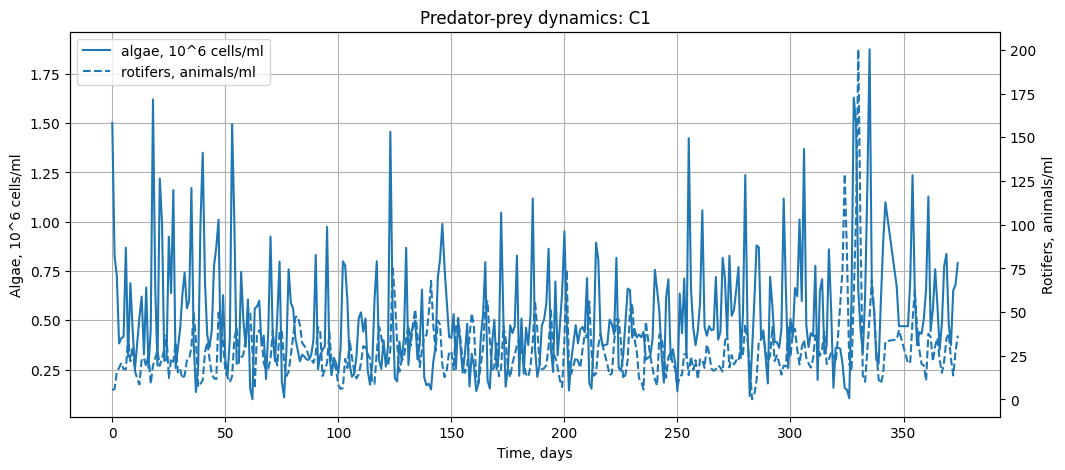

In [ ]:
def plot_cycle(cycle_id: str):
    subset = data[data["cycle_id"] == cycle_id].copy()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(
        subset["time"],
        subset["algae"],
        label="algae, 10^6 cells/ml"
    )
    ax1.set_xlabel("Time, days")
    ax1.set_ylabel("Algae, 10^6 cells/ml")
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(
        subset["time"],
        subset["rotifers"],
        label="rotifers, animals/ml",
        linestyle="--"
    )
    ax2.set_ylabel("Rotifers, animals/ml")

    plt.title(f"Predator-prey dynamics: {cycle_id}")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

    plt.show()

plot_cycle("C1")

## Формирование окон для LSTM

In [ ]:
TIME_STEPS = 14
HORIZON = 1  # прогноз на 1 день вперед


def make_windows_for_cycle(
    df_cycle: pd.DataFrame,
    feature_cols: list,
    target_cols: list,
    time_steps: int,
    horizon: int = 1
):
    """Создает окна X/y для одного временного ряда."""
    df_cycle = df_cycle.sort_values("time").reset_index(drop=True)

    X, y, meta = [], [], []

    max_start = len(df_cycle) - time_steps - horizon + 1

    for start_idx in range(max_start):
        end_idx = start_idx + time_steps
        target_idx = end_idx + horizon - 1

        X.append(df_cycle.loc[start_idx:end_idx - 1, feature_cols].values)
        y.append(df_cycle.loc[target_idx, target_cols].values)

        meta.append({
            "cycle_id": df_cycle.loc[target_idx, "cycle_id"],
            "target_time": df_cycle.loc[target_idx, "time"],
            "last_input_time": df_cycle.loc[end_idx - 1, "time"]
        })

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), pd.DataFrame(meta)


def split_windows_by_time(X, y, meta, train_ratio=0.70, val_ratio=0.15):
    """Делит окна по времени внутри одного цикла: train -> validation -> test."""
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    return {
        "train": (X[:train_end], y[:train_end], meta.iloc[:train_end].reset_index(drop=True)),
        "val": (X[train_end:val_end], y[train_end:val_end], meta.iloc[train_end:val_end].reset_index(drop=True)),
        "test": (X[val_end:], y[val_end:], meta.iloc[val_end:].reset_index(drop=True)),
    }


parts = {"train": [], "val": [], "test": []}

for cycle_id in sorted(data["cycle_id"].unique()):
    df_cycle = data[data["cycle_id"] == cycle_id].copy()
    X_c, y_c, meta_c = make_windows_for_cycle(
        df_cycle,
        feature_cols=FEATURE_COLS,
        target_cols=TARGET_COLS,
        time_steps=TIME_STEPS,
        horizon=HORIZON
    )

    split_c = split_windows_by_time(X_c, y_c, meta_c)

    for split_name in parts:
        parts[split_name].append(split_c[split_name])

def concat_split(split_items):
    X = np.concatenate([item[0] for item in split_items], axis=0)
    y = np.concatenate([item[1] for item in split_items], axis=0)
    meta = pd.concat([item[2] for item in split_items], ignore_index=True)
    return X, y, meta

X_train_raw, y_train_raw, meta_train = concat_split(parts["train"])
X_val_raw, y_val_raw, meta_val = concat_split(parts["val"])
X_test_raw, y_test_raw, meta_test = concat_split(parts["test"])

print("X_train:", X_train_raw.shape, "y_train:", y_train_raw.shape)
print("X_val:  ", X_val_raw.shape, "y_val:  ", y_val_raw.shape)
print("X_test: ", X_test_raw.shape, "y_test: ", y_test_raw.shape)

display(meta_train.head())


X_train: (1271, 14, 6) y_train: (1271, 2)
X_val:   (274, 14, 6) y_val:   (274, 2)
X_test:  (278, 14, 6) y_test:  (278, 2)


,cycle_id,target_time,last_input_time
0,C1,14.0,13.0
1,C1,15.0,14.0
2,C1,16.0,15.0
3,C1,17.0,16.0
4,C1,18.0,17.0


## Масштабирование признаков


In [ ]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

n_features = X_train_raw.shape[-1]
n_targets = y_train_raw.shape[-1]

feature_scaler.fit(X_train_raw.reshape(-1, n_features))
target_scaler.fit(y_train_raw)

def scale_X(X_raw):
    X_scaled = feature_scaler.transform(X_raw.reshape(-1, n_features))
    return X_scaled.reshape(X_raw.shape).astype(np.float32)

def scale_y(y_raw):
    return target_scaler.transform(y_raw).astype(np.float32)

X_train = scale_X(X_train_raw)
X_val = scale_X(X_val_raw)
X_test = scale_X(X_test_raw)

y_train = scale_y(y_train_raw)
y_val = scale_y(y_val_raw)
y_test = scale_y(y_test_raw)

print("После масштабирования:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)


После масштабирования:
X_train: (1271, 14, 6) y_train: (1271, 2)
X_val:   (274, 14, 6) y_val:   (274, 2)
X_test:  (278, 14, 6) y_test:  (278, 2)


## 7. Построение LSTM-модели


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(SEED)

model = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, n_features), return_sequences=True),
    Dropout(0.20),
    LSTM(32),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(n_targets)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,154 (121.70 KB)

 Trainable params: 31,154 (121.70 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели


In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-5
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
    shuffle=False
)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0189 - mae: 0.0927 - val_loss: 0.0172 - val_mae: 0.1077 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0188 - mae: 0.0933 - val_loss: 0.0127 - val_mae: 0.0927 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0170 - mae: 0.0886 - val_loss: 0.0109 - val_mae: 0.0860 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0158 - mae: 0.0842 - val_loss: 0.0132 - val_mae: 0.0940 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0148 - mae: 0.0829 - val_loss: 0.0101 - val_mae: 0.0811 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0134 - mae: 0.0783 - val_loss: 0.0083 - val_mae: 0.0670 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0125 - mae: 0.0752 - val_loss: 0.0095 - val_mae: 0.0702 - learning_rate: 0.0010
Epoch 

## График обучения

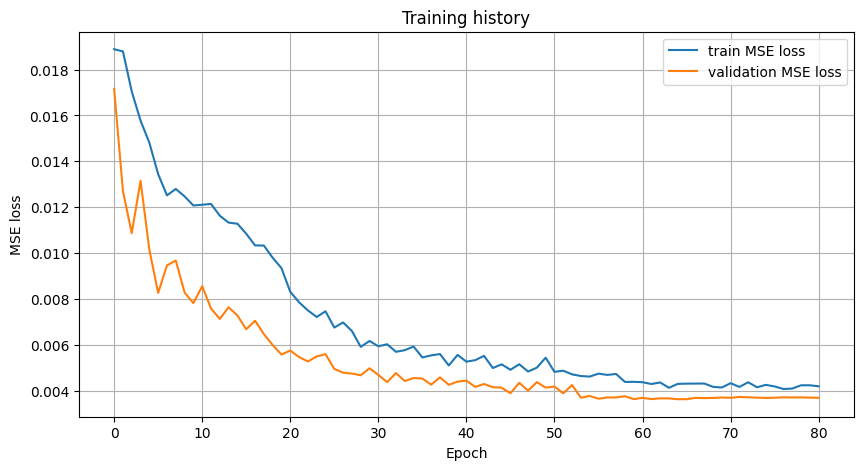

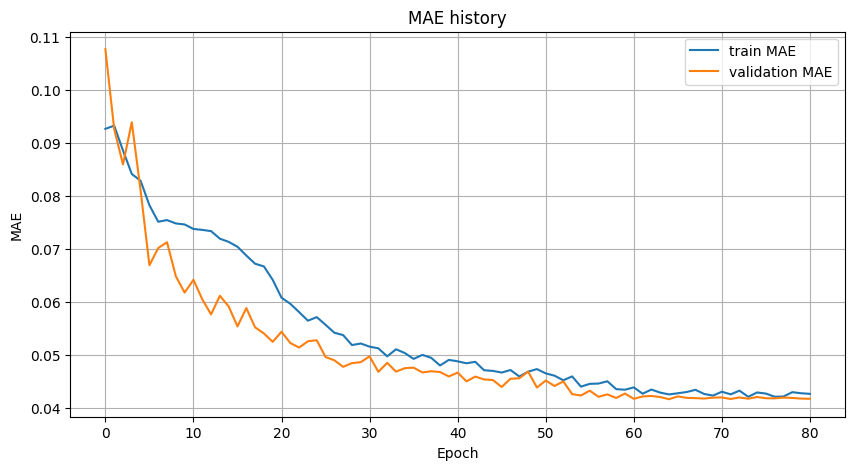

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train MSE loss")
plt.plot(history.history["val_loss"], label="validation MSE loss")
plt.title("Training history")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["mae"], label="train MAE")
plt.plot(history.history["val_mae"], label="validation MAE")
plt.title("MAE history")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


## Оценка качества прогноза на test


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Оценка модели в масштабированной шкале
test_loss_scaled, test_mae_scaled = model.evaluate(X_test, y_test, verbose=0)

print("Метрики в масштабированной шкале:")
print(f"Overall MSE: {test_loss_scaled:.6f}")
print(f"Overall MAE: {test_mae_scaled:.6f}")

# Прогноз в масштабированной шкале
y_pred_scaled = model.predict(X_test)

# Метрики по каждой переменной в масштабированной шкале
scaled_metrics_rows = []

for i, target in enumerate(TARGET_COLS):
    scaled_metrics_rows.append({
        "target": target,
        "MSE_scaled": mean_squared_error(y_test[:, i], y_pred_scaled[:, i]),
        "MAE_scaled": mean_absolute_error(y_test[:, i], y_pred_scaled[:, i])
    })

scaled_metrics_df = pd.DataFrame(scaled_metrics_rows)

display(scaled_metrics_df)


# Перевод прогноза обратно в исходную шкалу
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = y_test_raw.copy()

overall_mse = mean_squared_error(y_true, y_pred)
overall_mae = mean_absolute_error(y_true, y_pred)

print("\nМетрики в исходной шкале:")
print(f"Overall MSE: {overall_mse:.4f}")
print(f"Overall MAE: {overall_mae:.4f}")

# Метрики по каждой переменной в исходной шкале
metrics_rows = []

for i, target in enumerate(TARGET_COLS):
    metrics_rows.append({
        "target": target,
        "MSE": mean_squared_error(y_true[:, i], y_pred[:, i]),
        "MAE": mean_absolute_error(y_true[:, i], y_pred[:, i])
    })

metrics_df = pd.DataFrame(metrics_rows)

display(metrics_df)

Метрики в масштабированной шкале:
Overall MSE: 0.008207
Overall MAE: 0.052634
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


,target,MSE_scaled,MAE_scaled
0,algae,0.007160,0.047091
1,rotifers,0.009255,0.058177



Метрики в исходной шкале:
Overall MSE: 105.3517
Overall MAE: 4.5760


,target,MSE,MAE
0,algae,0.476163,0.384040
1,rotifers,210.227188,8.767944


## Таблица результатов прогноза

Дополнительно считаем не только прогноз следующего значения, но и прогноз изменения относительно последнего дня входного окна.


In [ ]:
results = meta_test.copy()

for i, target in enumerate(TARGET_COLS):
    results[f"{target}_actual"] = y_true[:, i]
    results[f"{target}_predicted"] = y_pred[:, i]

    # Последнее известное значение во входном окне
    last_input_values = X_test_raw[:, -1, FEATURE_COLS.index(target)]
    results[f"{target}_last_input"] = last_input_values

    # Изменение численности: следующее значение минус последнее наблюдение
    results[f"{target}_actual_change"] = results[f"{target}_actual"] - results[f"{target}_last_input"]
    results[f"{target}_predicted_change"] = results[f"{target}_predicted"] - results[f"{target}_last_input"]

display(results.head(20))

,cycle_id,target_time,last_input_time,algae_actual,algae_predicted,algae_last_input,algae_actual_change,algae_predicted_change,rotifers_actual,rotifers_predicted,rotifers_last_input,rotifers_actual_change,rotifers_predicted_change
0,C1,320.0,319.0,0.360000,0.473583,0.157500,0.202500,0.316083,21.038422,21.641562,25.764999,-4.726578,-4.123438
1,C1,321.0,320.0,0.360000,0.470565,0.360000,0.000000,0.110565,35.643684,25.955027,21.038422,14.605263,4.916605
2,C1,322.0,321.0,0.356311,0.435713,0.360000,-0.003689,0.075713,54.166885,30.099962,35.643684,18.523201,-5.543722
3,C1,323.0,322.0,0.282541,0.371762,0.356311,-0.073770,0.015450,73.904587,31.406328,54.166885,19.737701,-22.760557
4,C1,324.0,323.0,0.156078,0.367069,0.282541,-0.126463,0.084528,129.021072,53.888573,73.904587,55.116486,-20.016014
5,C1,325.0,324.0,0.147143,0.280905,0.156078,-0.008936,0.124827,82.328857,43.987823,129.021072,-46.692215,-85.033249
6,C1,326.0,325.0,0.105000,0.318379,0.147143,-0.042143,0.171236,20.223801,27.302399,82.328857,-62.105057,-55.026459
7,C1,327.0,326.0,0.610300,0.381807,0.105000,0.505300,0.276807,16.079500,17.558502,20.223801,-4.144300,-2.665298
8,C1,328.0,327.0,1.629072,0.474853,0.610300,1.018772,-0.135447,59.026081,16.005213,16.079500,42.946579,-0.074287
9,C1,329.0,328.0,1.505846,0.813515,1.629072,-0.123226,-0.815557,103.795227,57.504261,59.026081,44.769146,-1.521820


## Визуализация прогноза

Циклы в test: ['C1' 'C10' 'C2' 'C3' 'C4' 'C5' 'C6' 'C7' 'C8' 'C9']


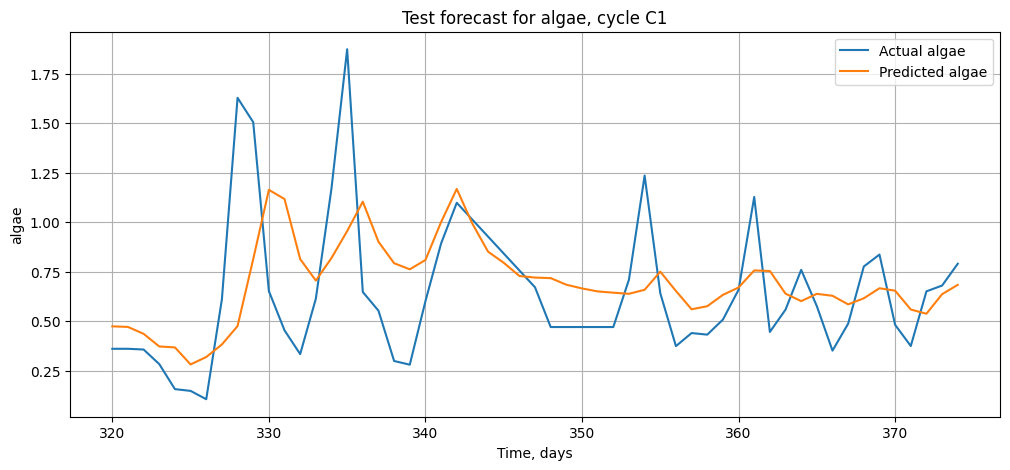

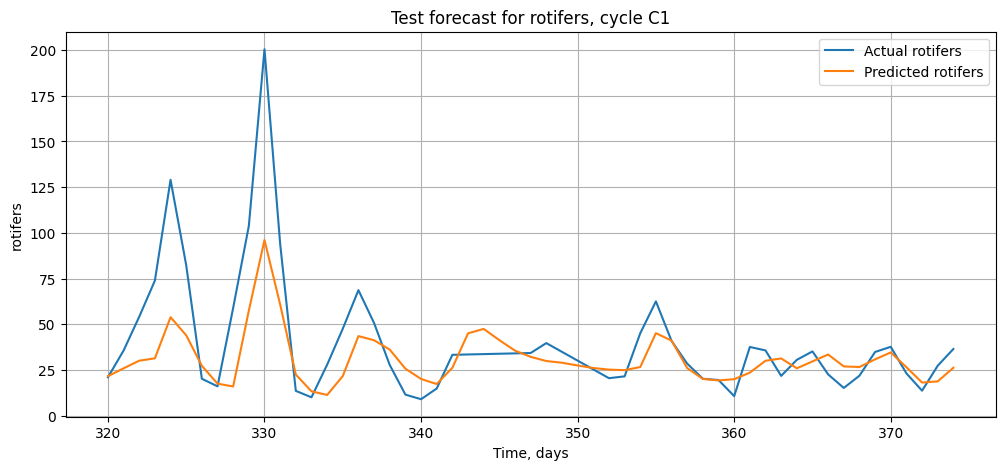

In [ ]:
def plot_predictions_for_cycle(cycle_id: str):
    subset = results[results["cycle_id"] == cycle_id].sort_values("target_time").copy()

    if subset.empty:
        print(f"В test-части нет наблюдений для {cycle_id}. Доступные циклы:")
        print(results["cycle_id"].unique())
        return

    for target in TARGET_COLS:
        plt.figure(figsize=(12, 5))
        plt.plot(subset["target_time"], subset[f"{target}_actual"], label=f"Actual {target}")
        plt.plot(subset["target_time"], subset[f"{target}_predicted"], label=f"Predicted {target}")
        plt.title(f"Test forecast for {target}, cycle {cycle_id}")
        plt.xlabel("Time, days")
        plt.ylabel(target)
        plt.legend()
        plt.grid(True)
        plt.show()


print("Циклы в test:", results["cycle_id"].unique())
plot_predictions_for_cycle(results["cycle_id"].iloc[0])


## Вывод


Динамика algae и rotifers имеет выраженный циклический характер. Algae выступает ресурсом для rotifers, поэтому изменения одной популяции связаны с изменениями другой. При росте численности rotifers нагрузка на ресурс увеличивается, что может сопровождаться снижением уровня algae. При этом популяция rotifers изменяется более резко и содержит сильные всплески, тогда как algae имеет меньший масштаб значений и более сглаженную динамику.

Модель в целом улавливает направление изменений и общий характер временного ряда. Однако при резких скачках численности, особенно у rotifers, прогноз становится менее точным. LSTM-модель склонна сглаживать экстремальные значения и не всегда точно воспроизводит внезапные пики или резкие падения. Это соответствует ожидаемому результату, так как резкое сокращение или восстановление популяции является наиболее сложным участком для прогнозирования.

Ошибки по отдельным переменным подтверждают эту закономерность. Прогноз для algae оказался точнее, чем для rotifers: в исходной шкале MAE для algae составил 0,384040, а для rotifers 8,767944. Такая разница связана с тем, что rotifers имеют более широкий диапазон значений и более нестабильную динамику. В целом результаты показывают, что LSTM-модель справилась с задачей, но точность прогноза снижается на участках с резкими изменениями численности.
